# Fine-Tuning DistilBERT for Three-Class Sentiment Classification of Amazon Electronics Reviews

## Project overview

This notebook implements a deep learning solution for three-class sentiment classification using **50,000 Amazon Electronics reviews**.

The task is to classify review text into three sentiment classes:

- **Negative**: rating 1–2
- **Neutral**: rating 3
- **Positive**: rating 4–5

The model used is **DistilBERT**, a pre-trained Transformer encoder. DistilBERT already contains its own token embeddings, positional information, and Transformer encoder layers. Therefore, this notebook does not manually create a separate embedding layer. Instead, it fine-tunes a pre-trained DistilBERT model with a three-class classification head.

## How to run

This notebook is designed to be reproducible in the assessment environment using:

- Kernel: Python 3.10 - AzureML
- Recommended hardware: GPU

The notebook was developed and tested on Google Colab using a T4 GPU. The implementation uses standard PyTorch and Hugging Face Transformers, so a CUDA-compatible GPU is recommended for faster training.

To reproduce the project:

1. Open this notebook in Azure or Google Colab.
2. Select a Python 3.10-compatible environment.
3. Enable GPU acceleration if available.
4. Click "Run All".
5. The notebook will install dependencies, stream 50,000 Amazon Electronics reviews from a remote dataset URL, fine-tune DistilBERT, and evaluate the results.


## Runtime note

The dataset extraction is fixed at **50,000 reviews**. To support reproducibility in the marking environment, the model is fine-tuned for **one epoch** by default. This keeps the notebook suitable for "Run All" execution while still preserving the full data loading, training, validation, testing, and error analysis pipeline.

In a fuller experimental setting, I would train for approximately **3–5 epochs** and apply early stopping based on validation macro-F1. This would allow the model to adapt further to the Amazon Electronics review domain while limiting overfitting and runtime cost.

## Dataset source and acknowledgement

This notebook streams the Amazon Electronics review file from the Amazon Reviews 2023 collection hosted on Hugging Face.

Dataset file URL:

- https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl

The full dataset citation and related academic references are provided in the accompanying critical reflection report.

## 1. Install dependencies

This cell installs the libraries required for loading the remote dataset, using the Hugging Face Transformer model, and evaluating the classification results.

In [1]:
%pip install -q datasets transformers scikit-learn pandas matplotlib tqdm

## 2. Import libraries and set reproducibility controls

This cell imports the required libraries and fixes random seeds. Reproducibility is important because model training involves random operations such as data shuffling and parameter initialisation.

In [2]:
import os
import re
import random
import itertools
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, Dataset as HFDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# These settings improve reproducibility, although exact determinism may still vary across hardware.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("PyTorch version:", torch.__version__)

if device.type == "cpu":
    print("Warning: No GPU was detected. DistilBERT fine-tuning on CPU may be very slow.")

Using device: cuda
PyTorch version: 2.10.0+cu128


## 3. Load 50,000 Amazon Electronics reviews from a remote source

The dataset is streamed from Hugging Face and the first 50,000 Electronics reviews are extracted. This follows the same general dataset loading logic used in the group assessment dataset notebook: the data is obtained programmatically from a remote source rather than from a local file.

In [3]:
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

N_REVIEWS = 50000

ds_iter = load_dataset(
    "json",
    data_files=REVIEWS_URL,
    split="train",
    streaming=True
)

# Extract exactly 50,000 reviews from the streamed dataset.
sample = list(itertools.islice(ds_iter, N_REVIEWS))

dataset = HFDataset.from_list(sample)
df = dataset.to_pandas()

print(f"Working dataset size: {len(df):,} reviews")
print("Available columns:")
print(df.columns.tolist())

display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Working dataset size: 50,000 reviews
Available columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


## 4. Inspect the original data

Before converting ratings into sentiment labels, this cell checks missing values, the original rating distribution, and the first few review examples. This helps identify whether the data is suitable for sentiment classification.

Dataset shape: (50000, 10)

Missing values in important columns:
text      0
rating    0
dtype: int64

Original rating distribution:
rating
1.0     4144
2.0     2117
3.0     3412
4.0     7383
5.0    32944
Name: count, dtype: int64


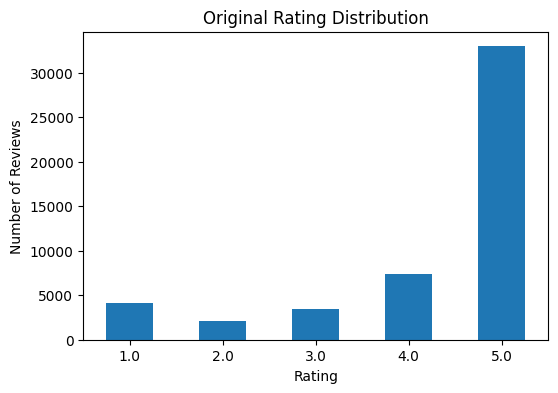

,title,text,rating,verified_purchase,helpful_vote
0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,3.0,True,0
1,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,1.0,True,0
2,Excellent!,I love these. They even come with a carry case...,5.0,True,0
3,Great laptop backpack!,I was searching for a sturdy backpack for scho...,5.0,True,18
4,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,5.0,True,0


In [4]:
print("Dataset shape:", df.shape)

required_columns = ["text", "rating"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Required column missing from dataset: {col}")

print("\nMissing values in important columns:")
print(df[required_columns].isna().sum())

print("\nOriginal rating distribution:")
print(df["rating"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Original Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

preview_columns = [col for col in ["title", "text", "rating", "verified_purchase", "helpful_vote"] if col in df.columns]
display(df[preview_columns].head())

## 5. Convert star ratings into three sentiment classes

The original ratings are converted into three sentiment labels:

- 1–2 stars: Negative
- 3 stars: Neutral
- 4–5 stars: Positive

This creates a supervised three-class text classification task.

Dataset size after dropping missing text/rating: 50000

Sentiment class distribution:
label_name
Positive    40327
Negative     6261
Neutral      3412
Name: count, dtype: int64

Sentiment class distribution percentage:
label_name
Positive    0.80654
Negative    0.12522
Neutral     0.06824
Name: proportion, dtype: float64


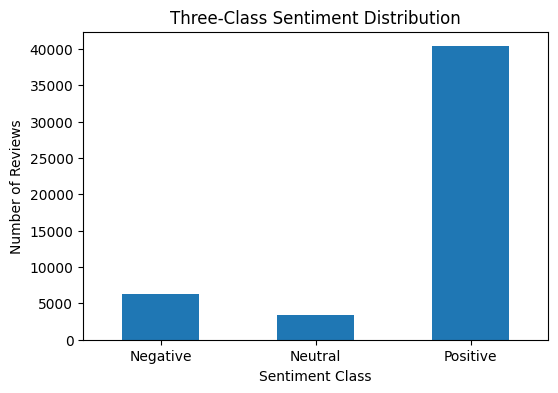

,rating,label,label_name,text
0,3.0,1,Neutral,First & most offensive: they reek of gasoline ...
1,1.0,0,Negative,These didn’t work. Idk if they were damaged in...
2,5.0,2,Positive,I love these. They even come with a carry case...
3,5.0,2,Positive,I was searching for a sturdy backpack for scho...
4,5.0,2,Positive,I've bought these headphones three times becau...


In [5]:
def rating_to_sentiment_label(rating):
    rating = float(rating)

    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive


label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

id2label = label_names
label2id = {v: k for k, v in id2label.items()}

# Keep only rows with valid text and rating.
df = df.dropna(subset=["text", "rating"]).copy()
df["text"] = df["text"].astype(str)

df["label"] = df["rating"].apply(rating_to_sentiment_label)
df["label_name"] = df["label"].map(label_names)

print("Dataset size after dropping missing text/rating:", len(df))

print("\nSentiment class distribution:")
print(df["label_name"].value_counts())

print("\nSentiment class distribution percentage:")
print(df["label_name"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
df["label_name"].value_counts().reindex(["Negative", "Neutral", "Positive"]).plot(kind="bar")
plt.title("Three-Class Sentiment Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

display(df[["rating", "label", "label_name", "text"]].head())

## 6. Clean text and analyse review length

DistilBERT has its own tokenizer, so heavy manual text preprocessing is not required. The cleaning step here is intentionally light: it removes HTML fragments and extra whitespace while preserving the main wording of each review.

Review length is inspected to justify the maximum token length used later.

Dataset size after text cleaning: 49991

Review length statistics:
count    49991.000000
mean        67.789162
std        104.127088
min          1.000000
25%         12.000000
50%         34.000000
75%         78.000000
max       1999.000000
Name: word_count, dtype: float64


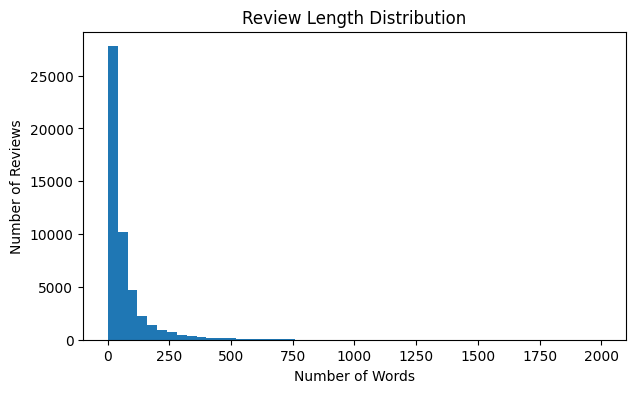

,text,clean_text,rating,label_name
0,First & most offensive: they reek of gasoline ...,First & most offensive: they reek of gasoline ...,3.0,Neutral
1,These didn’t work. Idk if they were damaged in...,These didn’t work. Idk if they were damaged in...,1.0,Negative
2,I love these. They even come with a carry case...,I love these. They even come with a carry case...,5.0,Positive
3,I was searching for a sturdy backpack for scho...,I was searching for a sturdy backpack for scho...,5.0,Positive
4,I've bought these headphones three times becau...,I've bought these headphones three times becau...,5.0,Positive


In [6]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

print("Dataset size after text cleaning:", len(df))

print("\nReview length statistics:")
print(df["word_count"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df["word_count"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

display(df[["text", "clean_text", "rating", "label_name"]].head())

## 7. Split the data into training, validation, and test sets

The data is split using a **stratified 70/15/15 split**:

- 70% training set
- 15% validation set
- 15% test set

Stratification preserves the approximate Negative/Neutral/Positive class distribution across all three subsets. This is important because Amazon review ratings are usually imbalanced.

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["label_name"].value_counts(normalize=True).reindex(["Negative", "Neutral", "Positive"]))

print("\nValidation class distribution:")
print(val_df["label_name"].value_counts(normalize=True).reindex(["Negative", "Neutral", "Positive"]))

print("\nTest class distribution:")
print(test_df["label_name"].value_counts(normalize=True).reindex(["Negative", "Neutral", "Positive"]))

Train size: 34993
Validation size: 7499
Test size: 7499

Train class distribution:
label_name
Negative    0.125225
Neutral     0.068242
Positive    0.806533
Name: proportion, dtype: float64

Validation class distribution:
label_name
Negative    0.125217
Neutral     0.068276
Positive    0.806508
Name: proportion, dtype: float64

Test class distribution:
label_name
Negative    0.125217
Neutral     0.068276
Positive    0.806508
Name: proportion, dtype: float64


## 8. Load the DistilBERT tokenizer

DistilBERT uses a subword tokenizer. This avoids manually building a vocabulary and helps handle rare words, misspellings, and product-specific terms.

The maximum sequence length is set to 128 tokens as a practical trade-off between preserving review content and controlling GPU memory/runtime.

In [8]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Maximum sequence length:", MAX_LENGTH)

example_text = train_df.loc[0, "clean_text"]
example_encoding = tokenizer(
    example_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

print("\nExample review:")
print(example_text[:500])

print("\nFirst 20 token IDs:")
print(example_encoding["input_ids"][:20])

print("\nDecoded first tokens:")
print(tokenizer.decode(example_encoding["input_ids"][:30]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Maximum sequence length: 128

Example review:
Update!!: my review below was originally written 07/2019. I wanted to add an update THREE years later, 07/2022. This little laptop is still kicking. I use it every single day from comfort of my couch to write reviews, do basic doomscrolling (lol), write emails, etc. Camera still works. Speakers still good. No major issues. I never did do any adjustments to it. Just sort of kept using it as is. I;m maxed out for memory, so it isnt something I would rely on for loading pictures onto, but as mentio

First 20 token IDs:
[101, 10651, 999, 999, 1024, 2026, 3319, 2917, 2001, 2761, 2517, 5718, 1013, 10476, 1012, 1045, 2359, 2000, 5587, 2019]

Decoded first tokens:
[CLS] update!! : my review below was originally written 07 / 2019. i wanted to add an update three years later, 07 / 2022.


## 9. Create PyTorch datasets and data loaders

This cell tokenizes the reviews and wraps them in a PyTorch Dataset. The model receives:

- `input_ids`: token IDs from the DistilBERT tokenizer
- `attention_mask`: identifies real tokens versus padding tokens
- `labels`: the three-class sentiment label

In [9]:
class AmazonReviewTransformerDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.texts = dataframe["clean_text"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Tokenise all texts once to avoid repeated tokenisation during training.
        self.encodings = self.tokenizer(
            self.texts,
            truncation=True,
            padding="max_length",
            max_length=self.max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item


BATCH_SIZE = 16

train_dataset = AmazonReviewTransformerDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = AmazonReviewTransformerDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = AmazonReviewTransformerDataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))

print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["labels"].shape)

Input IDs shape: torch.Size([16, 128])
Attention mask shape: torch.Size([16, 128])
Labels shape: torch.Size([16])


## 10. Load a pre-trained DistilBERT model with a three-class classification head

The model is loaded as `AutoModelForSequenceClassification` with `num_labels=3`.

This means the pre-trained DistilBERT encoder is combined with a task-specific classification layer for Negative, Neutral, and Positive sentiment prediction.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded:", MODEL_NAME)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Total parameters: 66,955,779
Trainable parameters: 66,955,779


## 11. Define class-weighted loss and optimisation settings

The original Amazon review distribution may be imbalanced, often with more positive reviews than neutral or negative reviews. To reduce majority-class dominance, this notebook uses class-weighted cross-entropy loss.

The optimiser is AdamW, which is commonly used for Transformer fine-tuning.

In [11]:
class_counts = train_df["label"].value_counts().sort_index()
num_classes = 3
total_train = len(train_df)

class_weights = total_train / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

print("Training class counts:")
print(class_counts)

print("\nClass weights:")
for idx, weight in enumerate(class_weights_tensor.detach().cpu().numpy()):
    print(f"{label_names[idx]}: {weight:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

LEARNING_RATE = 2e-5
EPOCHS = 1

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("\nTraining settings:")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)

Training class counts:
label
0     4382
1     2388
2    28223
Name: count, dtype: int64

Class weights:
Negative: 2.6619
Neutral: 4.8846
Positive: 0.4133

Training settings:
Learning rate: 2e-05
Epochs: 1
Batch size: 16
Total training steps: 2188
Warmup steps: 218


## 12. Define training and evaluation functions

The training loop performs supervised fine-tuning of DistilBERT. The evaluation function reports loss, accuracy, and macro-F1.

Macro-F1 is important because it gives equal weight to Negative, Neutral, and Positive classes, which is useful when the dataset is imbalanced.

In [12]:
def train_one_epoch(model, data_loader, criterion, optimizer, scheduler, device):
    model.train()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()

        # Gradient clipping improves training stability.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)
        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    progress_bar = tqdm(data_loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = criterion(logits, labels)

            total_loss += loss.item() * input_ids.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)

## 13. Fine-tune DistilBERT

The model is fine-tuned on the training set and monitored on the validation set. The best model is selected using validation macro-F1.

For assessment reproducibility, the default number of epochs is low. If more runtime is available, increasing epochs may improve convergence.

In [13]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_macro_f1 = -1.0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc, train_macro_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_acc, val_macro_f1, _, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_macro_f1"].append(train_macro_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_model_state = deepcopy(model.state_dict())

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Macro-F1: {train_macro_f1:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f}"
    )

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nLoaded best model based on validation macro-F1.")


Epoch 1/1


Training:   0%|          | 0/2188 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]

Train Loss: 0.6870 | Train Acc: 0.8141 | Train Macro-F1: 0.6235
Val Loss: 0.6052 | Val Acc: 0.8620 | Val Macro-F1: 0.6869

Loaded best model based on validation macro-F1.


## 14. Plot training curves

These plots help diagnose training behaviour. With only one epoch, the curves are limited, but they still document the training and validation results produced during the run.

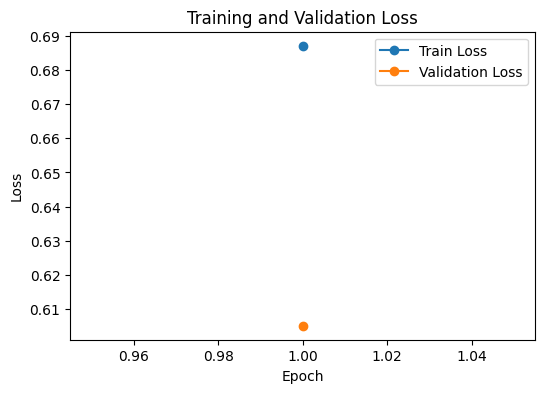

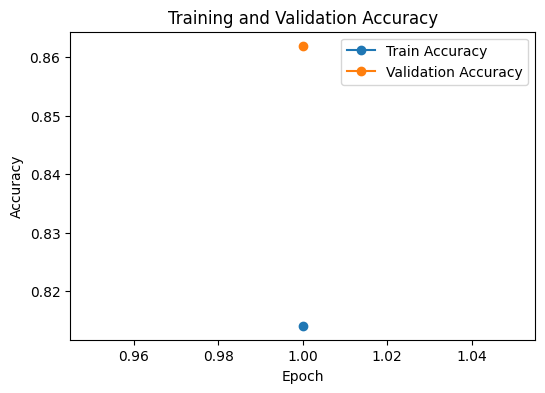

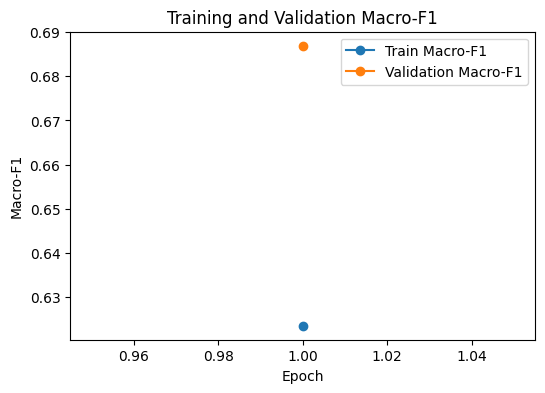

In [14]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_macro_f1"], marker="o", label="Train Macro-F1")
plt.plot(epochs, history["val_macro_f1"], marker="o", label="Validation Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.show()

## 15. Evaluate the final model on the test set

The test set is used only after training and validation. This gives a more realistic estimate of how the model performs on unseen reviews.

In [15]:
test_loss, test_acc, test_macro_f1, test_labels, test_preds, test_probs = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]

Test Loss: 0.6174
Test Accuracy: 0.8578
Test Macro-F1: 0.6777

Classification Report:
              precision    recall  f1-score   support

    Negative     0.6982    0.8009    0.7460       939
     Neutral     0.2893    0.4531    0.3531       512
    Positive     0.9696    0.9010    0.9340      6048

    accuracy                         0.8578      7499
   macro avg     0.6524    0.7183    0.6777      7499
weighted avg     0.8891    0.8578    0.8708      7499



## 16. Confusion matrix

The confusion matrix shows which sentiment classes are most often confused. This is especially useful for checking whether Neutral reviews are difficult to distinguish from Negative or Positive reviews.

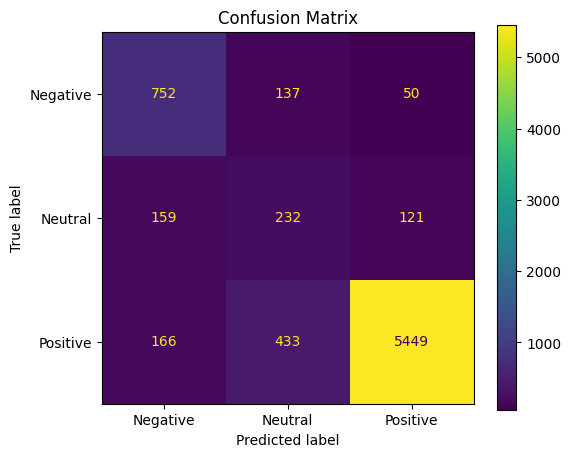

Confusion matrix:
[[ 752  137   50]
 [ 159  232  121]
 [ 166  433 5449]]


In [16]:
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.show()

print("Confusion matrix:")
print(cm)

## 17. Inspect prediction examples

This cell shows individual test examples with their true label, predicted label, and predicted class probabilities. This helps connect numerical metrics with real review text.

In [17]:
def predict_single_review(text):
    cleaned = clean_text(text)

    encoding = tokenizer(
        cleaned,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))

    return {
        "cleaned_text": cleaned,
        "predicted_label": label_names[pred],
        "negative_probability": probs[0],
        "neutral_probability": probs[1],
        "positive_probability": probs[2]
    }


sample_reviews = test_df.sample(8, random_state=SEED)

for _, row in sample_reviews.iterrows():
    result = predict_single_review(row["text"])

    print("=" * 100)
    print("Original rating:", row["rating"])
    print("True label:", row["label_name"])
    print("Predicted label:", result["predicted_label"])
    print("Probabilities:")
    print(f"  Negative: {result['negative_probability']:.4f}")
    print(f"  Neutral:  {result['neutral_probability']:.4f}")
    print(f"  Positive: {result['positive_probability']:.4f}")
    print("\nReview text:")
    print(row["text"][:700])

Original rating: 5.0
True label: Positive
Predicted label: Positive
Probabilities:
  Negative: 0.0097
  Neutral:  0.0456
  Positive: 0.9447

Review text:
You will not be disappointed with these earphones. I use mine at night to listen to podcasts (note: also keeps spiders out of your ears). The sound is great and the noise cancellation superb. I have a number of headphones and some work better than others. When I sleep at night, I always wear my headphones. All I hear is what I am listening to with these. Some of my other noise cancellation headphones don't cancel the noise as much. Others don't have as nice of sound. I like these so far the most.
Original rating: 4.0
True label: Positive
Predicted label: Positive
Probabilities:
  Negative: 0.0274
  Neutral:  0.2140
  Positive: 0.7586

Review text:
Hard to find a small 3 foot 3 outlet extension.  Nice small footprint.  I took one star of the the high price.
Original rating: 1.0
True label: Negative
Predicted label: Negative
Probabiliti

## 18. Error analysis

This cell displays examples where the model prediction differs from the rating-derived label. These examples are useful for critical reflection because errors may be caused by ambiguous wording, mixed sentiment, sarcasm, or imperfect rating-based labels.

In [18]:
test_results_df = test_df.copy().reset_index(drop=True)
test_results_df["pred_label"] = test_preds
test_results_df["pred_label_name"] = test_results_df["pred_label"].map(label_names)
test_results_df["correct"] = test_results_df["label"] == test_results_df["pred_label"]

misclassified_df = test_results_df[test_results_df["correct"] == False]

print("Number of misclassified examples:", len(misclassified_df))
print("Misclassification rate:", len(misclassified_df) / len(test_results_df))

display(
    misclassified_df[
        ["rating", "label_name", "pred_label_name", "text"]
    ].head(10)
)

Number of misclassified examples: 1066
Misclassification rate: 0.1421522869715962


,rating,label_name,pred_label_name,text
10,5.0,Positive,Negative,Had to have for Echo Show
13,3.0,Neutral,Positive,Feels cheaper than the one we had previously
18,3.0,Neutral,Negative,Too light weight for me.
20,3.0,Neutral,Negative,"great for the money, but it's thin plastic wra..."
24,5.0,Positive,Neutral,It is great for getting out big messes without...
32,4.0,Positive,Negative,I usually love Logitech. This particular set ...
33,3.0,Neutral,Positive,"But for what you pay, this is a decent wireles..."
59,5.0,Positive,Neutral,I thought my 6 plug/2 USB power strip was defe...
70,4.0,Positive,Neutral,I don’t have a ton to say about this protector...
76,2.0,Negative,Neutral,So these are not bad cameras or great ones. T...


## 19. Lightweight confidence analysis

This cell identifies the model's least confident predictions in the test set. Low-confidence cases are often useful for reflection because they may correspond to ambiguous or mixed-sentiment reviews.

In [19]:
max_probs = test_probs.max(axis=1)

test_results_df["model_confidence"] = max_probs

least_confident = test_results_df.sort_values("model_confidence").head(10)

display(
    least_confident[
        ["rating", "label_name", "pred_label_name", "model_confidence", "text"]
    ]
)

,rating,label_name,pred_label_name,model_confidence,text
2300,4.0,Positive,Negative,0.350946,Update 10/21/21: The thinness I talked about b...
3366,4.0,Positive,Neutral,0.353317,7740 hp printer pages remaining >1200 on colo...
2396,1.0,Negative,Negative,0.358448,"I couldn’t get a good photo, but I’ve never ha..."
360,5.0,Positive,Neutral,0.363070,Only place I can still get VHS tapes so i can ...
7180,5.0,Positive,Neutral,0.363686,a BEAST
6731,5.0,Positive,Neutral,0.368417,"If you have purchased a laptop lately, you hav..."
2445,5.0,Positive,Negative,0.370783,I bought this in August of 2012. I have used i...
6036,3.0,Neutral,Positive,0.373890,"Great for cells phones, great price too. ONLY ..."
6553,1.0,Negative,Neutral,0.378864,Arrived with bent screen protectors.
4799,5.0,Positive,Positive,0.383198,"For months, I used my Prime by itself with exc..."


# Notebook Summary and Reflection Points

This notebook implemented a three-class sentiment classification pipeline using 50,000 Amazon Electronics reviews and a fine-tuned pre-trained DistilBERT model.

The main implementation stages were:

1. Remote loading of 50,000 Amazon Electronics reviews.
2. Conversion of 1–5 star ratings into three sentiment classes:
   - 1–2 stars: Negative
   - 3 stars: Neutral
   - 4–5 stars: Positive
3. Light text cleaning and exploratory data analysis.
4. Stratified 70/15/15 train-validation-test split.
5. Loading of a pre-trained DistilBERT tokenizer and sequence classification model.
6. Supervised fine-tuning using class-weighted cross-entropy to reduce the effect of class imbalance.
7. Evaluation using accuracy, macro-F1, per-class precision, recall, F1-score, and confusion matrix.
8. Error analysis and low-confidence prediction inspection.

## Key Reflection Points for the Report

- DistilBERT was selected because it provides contextual pre-trained language representations, making it more suitable for review sentiment classification than models trained from scratch using simple word embeddings.

- The task is more complex than binary sentiment classification because Neutral reviews may contain mixed sentiment rather than a clearly neutral emotional tone.

- Star ratings were used as proxy labels for sentiment. However, they are imperfect indicators of true textual sentiment because a numerical rating may not fully match the emotional content of the review text.

- Accuracy alone is insufficient for evaluating this model because the dataset is class-imbalanced, with Positive reviews forming the majority class.

- Macro-F1 and per-class precision, recall, and F1-score are therefore important because they show whether the model performs reasonably across Negative, Neutral, and Positive classes.

- DistilBERT may outperform simpler embedding-based models because it captures contextual meaning, negation, and contrast. However, this comes with higher computational cost, longer runtime, and lower interpretability.

- The model was fine-tuned for one epoch to keep the notebook reproducible within the assessment runtime constraint. In a fuller experimental setting, I would train for approximately 3–5 epochs and apply early stopping based on validation macro-F1.

- The main limitation observed in the results is the weak performance on the Neutral class. This may be caused by class imbalance, the semantic ambiguity of 3-star reviews, and the imperfect mapping between star ratings and actual textual sentiment.